What is EDA?

Exploratory Data Analysis (EDA) means visually exploring your data before building any model. You're answering questions like:

What does the grade distribution look like?

Which factors most affect the final grade?

Are there any surprising patterns?

In [1]:
pip install matplotlib seaborn
# Here we are installing matplotlib and
#seaborn libraries which is we will use for visualization And (EDA)

In [2]:
#Exploratory data Analysis (EDA)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
from google.colab import files
uploaded = files.upload()

Saving student-mat.csv to student-mat.csv


In [7]:
df =pd.read_csv('student-mat.csv',sep=';')
sns.set_theme(style="whitegrid")

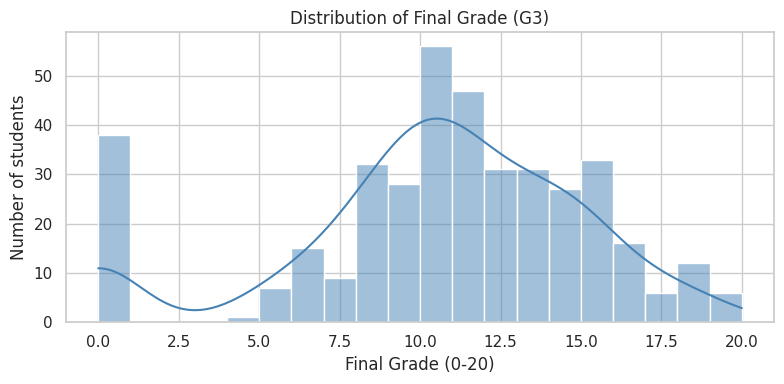

In [8]:
# 1st chart(Grade dist)
plt.figure(figsize=(8,4))
sns.histplot(df['G3'], bins=20, kde=True, color='steelblue')
plt.title('Distribution of Final Grade (G3)')
plt.xlabel('Final Grade (0-20)')
plt.ylabel('Number of students')
plt.tight_layout()
plt.savefig('final_grade_distribution.png')
plt.show()

 The histogram shows how the students performed in their final grades (G3).

 Most students scored either very low marks (0–5) or average marks around 10–12.

 Only a small number of students achieved high grades above 15.

 Overall, the chart suggests that many students struggled with their studies, while fewer students performed exceptionally well.

 (Grade Distribution is the first thing any data scientist looks at. The bell shape tells you it's roughly normal data, which most ML algorithms handle well. The spike of ~38 students at grade 0 is a red flag — those are likely dropouts, not poor performers. You may want to remove them later or treat them separately.)

/tmp/ipykernel_3707/3010861462.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='studytime', y='G3', data=df, palette='Blues')


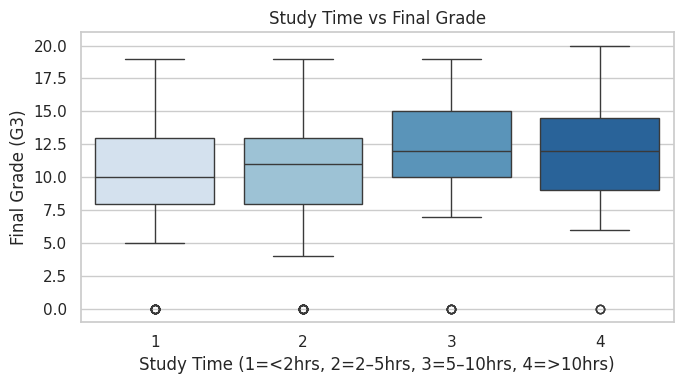

In [9]:
#chart2 (Study time)
plt.figure(figsize=(7, 4))
sns.boxplot(x='studytime', y='G3', data=df, palette='Blues')
plt.title('Study Time vs Final Grade')
plt.xlabel('Study Time (1=<2hrs, 2=2–5hrs, 3=5–10hrs, 4=>10hrs)')
plt.ylabel('Final Grade (G3)')
plt.tight_layout()
plt.savefig('chart2_studytime_vs_grade.png')
plt.show()

Study time 1 = less than 2 hrs/week. Study time 4 = over 10 hrs/week. The median grade rises as study time increases — but notice the boxes are wide (high spread). Many students who study a lot still score low, and vice versa.

What this means for your model: studytime is a useful feature but not a perfect predictor on its own. The model needs multiple features working together.

/tmp/ipykernel_3707/972094324.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='failures', y='G3', data=df, palette='Reds')


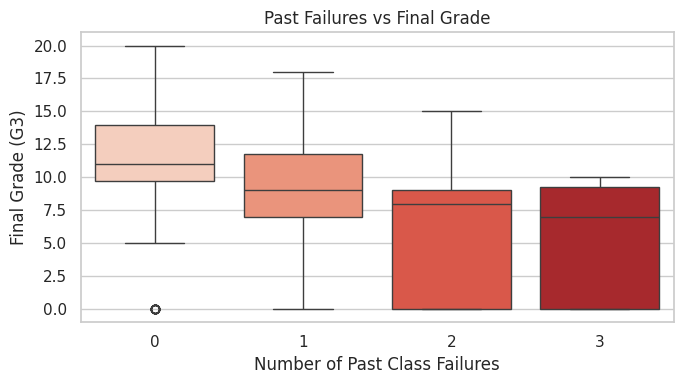

In [10]:
#chart3 (failures)
plt.figure(figsize=(7, 4))
sns.boxplot(x='failures', y='G3', data=df, palette='Reds')
plt.title('Past Failures vs Final Grade')
plt.xlabel('Number of Past Class Failures')
plt.ylabel('Final Grade (G3)')
plt.tight_layout()
plt.savefig('chart3_failures_vs_grade.png')
plt.show()

his is your strongest non-grade predictor. Students with 0 past failures average around 11. Students with 3 past failures average around 6. The drop is large and consistent — almost no overlap in the boxes.

What this means for your model: failures will be one of the most important features. In Stage 4 when you check feature importance, expect it to rank very high.

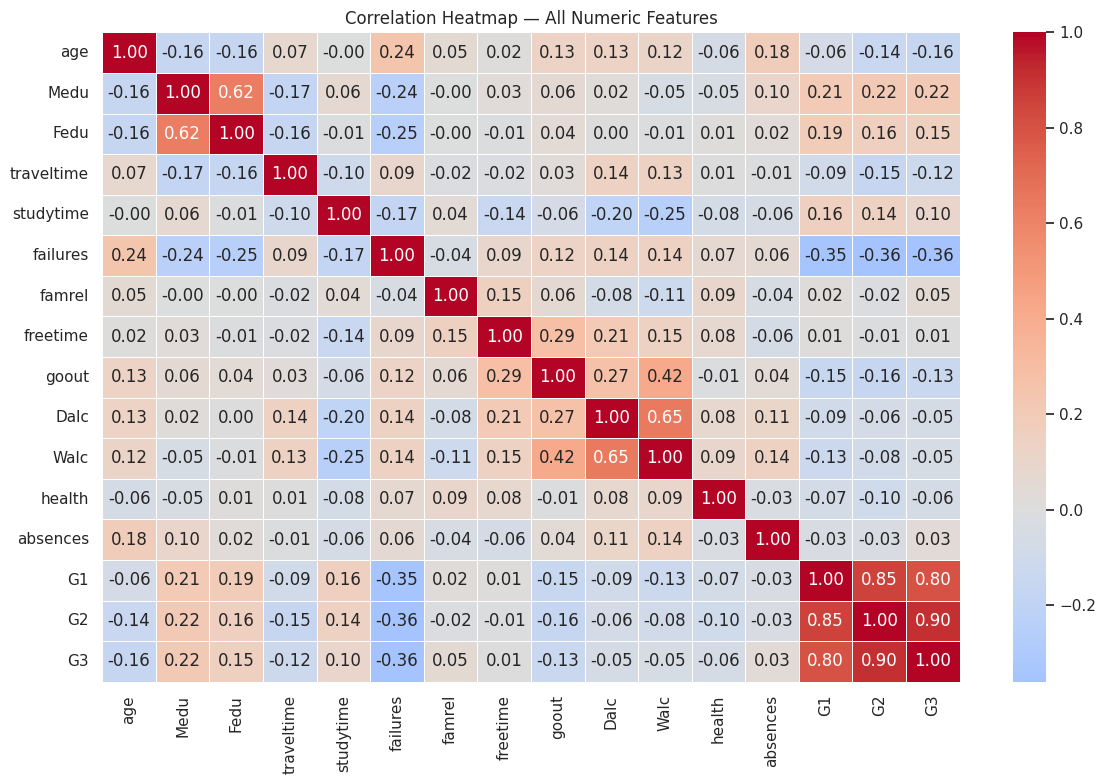

In [11]:
#chart4(Heatmap correlation)
plt.figure(figsize=(12, 8))
numeric_df = df.select_dtypes(include='number')
correlation = numeric_df.corr()

sns.heatmap(
    correlation,
    annot=True,          # show numbers inside boxes
    fmt='.2f',           # round to 2 decimal places
    cmap='coolwarm',     # red = positive, blue = negative
    center=0,
    linewidths=0.5
)
plt.title('Correlation Heatmap — All Numeric Features')
plt.tight_layout()
plt.savefig('chart4_correlation_heatmap.png')
plt.show()

The heatmap shows a number between -1 and +1 for every pair of columns. Closer to +1 = strong positive relationship. Closer to -1 = strong negative. Close to 0 = no relationship.

G2 and G1 are near 0.9 — past grades almost perfectly predict future grades. failures is around -0.36 — more failures = lower grade. absences is weakly negative (-0.09).

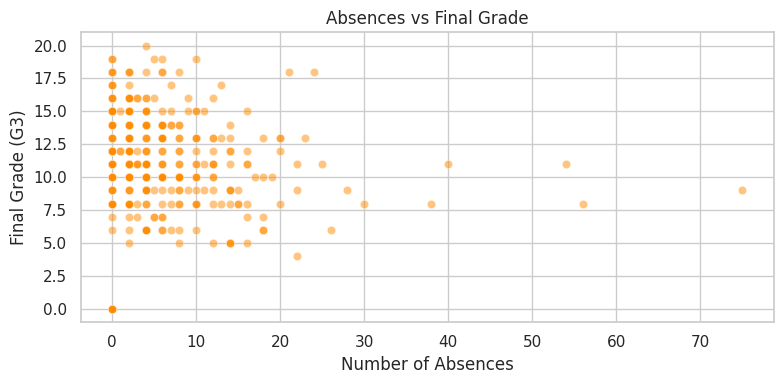

In [12]:
#chart5(Absences)
plt.figure(figsize=(8, 4))
sns.scatterplot(x='absences', y='G3', data=df, alpha=0.5, color='darkorange')
plt.title('Absences vs Final Grade')
plt.xlabel('Number of Absences')
plt.ylabel('Final Grade (G3)')
plt.tight_layout()
plt.savefig('chart5_absences_vs_grade.png')
plt.show()

Most students have under 20 absences. A few have 50–75, and they tend to score lower. But the trend is weak — many students with high absences still score okay, and many with low absences score poorly.

What this means for your model: Include it as a feature, but don't rely on it heavily. It adds small signal when combined with other features.

/tmp/ipykernel_3707/2321165097.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='sex', y='G3', data=df, palette='Set2')


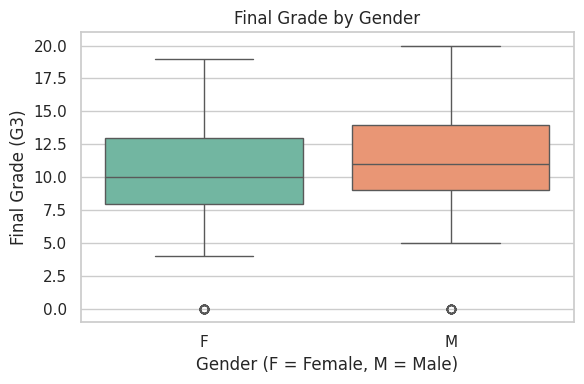

In [13]:
#chart6(Gender)
plt.figure(figsize=(6, 4))
sns.boxplot(x='sex', y='G3', data=df, palette='Set2')
plt.title('Final Grade by Gender')
plt.xlabel('Gender (F = Female, M = Male)')
plt.ylabel('Final Grade (G3)')
plt.tight_layout()
plt.savefig('chart6_grade_by_gender.png')
plt.show()

Female students score slightly higher on average (~11 vs ~10), but the difference is small and the boxes heavily overlap. Both groups have a wide spread of grades.

What this means for your model: sex adds a tiny bit of signal. Keep it in, but it will rank low in feature importance. The overlap means gender alone cannot predict grade.

/tmp/ipykernel_3707/2007746657.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='internet', y='G3', data=df, palette='Set1')


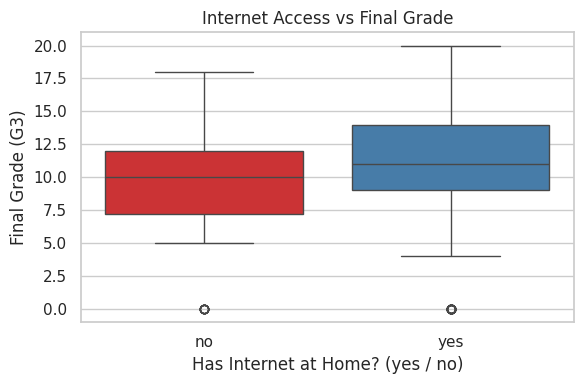

In [14]:
#chart7(Internet)
plt.figure(figsize=(6, 4))
sns.boxplot(x='internet', y='G3', data=df, palette='Set1')
plt.title('Internet Access vs Final Grade')
plt.xlabel('Has Internet at Home? (yes / no)')
plt.ylabel('Final Grade (G3)')
plt.tight_layout()
plt.savefig('chart7_internet_vs_grade.png')
plt.show()

Students with internet access at home score about 1 point higher on average. The medians are close but internet students have a slightly higher ceiling.

What this means for your model: Encode "yes"=1 and "no"=0 in Stage 3 preprocessing. It adds minor signal. Interestingly, internet alone doesn't guarantee high grades — access matters but so does how you use it.

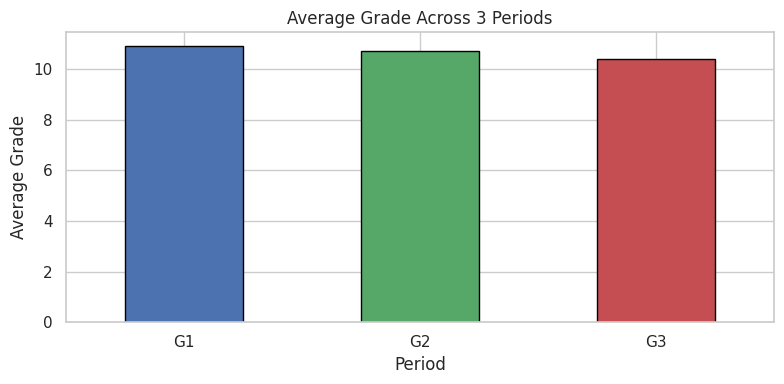

In [15]:
#chart8(Periods)
plt.figure(figsize=(8, 4))
df[['G1', 'G2', 'G3']].mean().plot(
    kind='bar',
    color=['#4C72B0', '#55A868', '#C44E52'],
    edgecolor='black'
)
plt.title('Average Grade Across 3 Periods')
plt.xlabel('Period')
plt.ylabel('Average Grade')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('chart8_period_grades.png')
plt.show()

Grades are very consistent across the year (all ~10.5), with a tiny dip at the final exam. This tells you the school year is relatively stable — students who start well tend to finish well.

Important decision for your model: G1 and G2 correlate with G3 at ~0.9. If you include them as features, your model will be very accurate but not very useful — you'd need previous grades to make a prediction. Try building two models: one with G1/G2 (more accurate) and one without (more realistic/useful).

## Summary of Exploratory Data Analysis (EDA)

This EDA focused on understanding factors influencing student final grades (G3).

### Key Findings:

*   **Final Grade Distribution (G3):** Many students scored very low (0-5) or average (10-12), with few achieving high grades (above 15). This suggests a segment of students struggling or dropping out, and another performing moderately.

*   **Study Time vs. G3:** While the median grade tends to increase with more study time, there's high variability. Students who study a lot can still score low, and vice versa. `studytime` is a useful but not standalone predictor.

*   **Past Failures vs. G3:** This is a strong predictor. Students with 0 failures average significantly higher grades (around 11) compared to those with 3 failures (around 6). `failures` is expected to be a highly important feature for prediction.

*   **Correlation Heatmap:**
    *   `G1` and `G2` (past grades) are highly correlated with `G3` (around 0.9), indicating strong predictability if previous grades are known. Including them makes the model accurate but less useful for *early* prediction.
    *   `failures` has a moderate negative correlation with `G3` (around -0.36).
    *   `absences` shows a weak negative correlation (-0.09).

*   **Absences vs. G3:** Most students have low absences, but even those with many absences can sometimes score well, and vice-versa. `absences` adds minor signal to the model.

*   **Gender vs. G3:** Female students show a slightly higher average grade, but the difference is small, and grade distributions overlap significantly. `sex` adds minimal signal.

*   **Internet Access vs. G3:** Students with internet access at home tend to score slightly higher. This is a minor signal and should be encoded (yes=1, no=0) for modeling.

*   **Grades Across Periods (G1, G2, G3):** Average grades are consistent across the school year, with a slight dip in the final exam. This suggests stability in student performance.

### Implications for Modeling:

*   `failures` will be a critical feature.
*   `G1` and `G2` are powerful predictors, but models using them predict *future* G3 based on *past* G1/G2. Consider building two models: one with G1/G2 for maximum accuracy, and one without for more practical early prediction.
*   Other features like `studytime`, `absences`, `sex`, and `internet` add smaller but potentially cumulative signals.
*   The spike of students with G3=0 might represent dropouts and could require special handling (e.g., removal or separate treatment) before final model training.

## Important Key Performance Indicators (KPIs)

| KPI                       | Description                                                                                                                                                             |
| :------------------------ | :---------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **Previous Grades (G1, G2)** | These are the strongest predictors of the final grade (G3), showing a high correlation (~0.9). They indicate a student's consistent academic performance.             |
| **Number of Past Failures** | This is a highly significant negative predictor. Students with more past failures consistently achieve lower final grades, making it a critical early warning sign. |
